#### Naive model

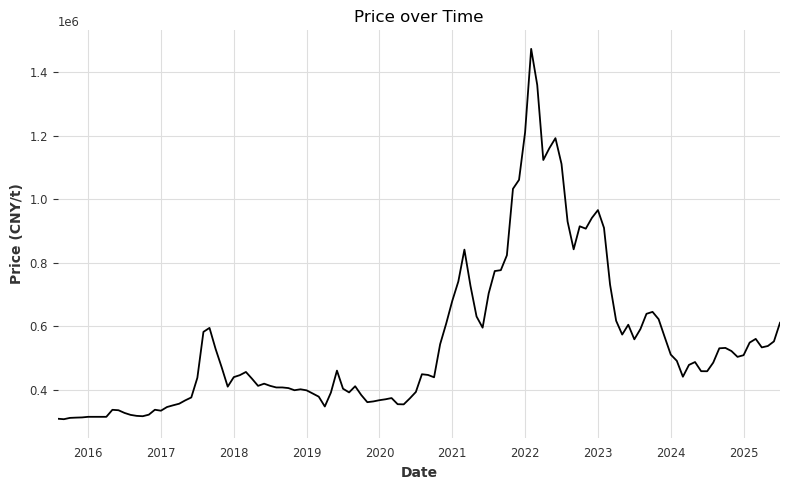

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries

# 날짜 컬럼을 파싱하면서 데이터 불러오기
data = pd.read_csv('data.csv', parse_dates=['date'])

# 날짜를 인덱스로 설정
data.set_index('date', inplace=True)
price = data['price(cny/t)']

plt.figure(figsize=(8, 5))
price.plot()
plt.title('Price over Time')
plt.xlabel('Date')
plt.ylabel('Price (CNY/t)')
plt.tight_layout()
plt.show()

In [3]:
# pandas Series를 darts TimeSeries로 변환
price = TimeSeries.from_series(price)
train, val = price.split_before(pd.Timestamp('2023-08-01'))
print(f"Training data: {len(train)} records")
print(f"Validation data: {len(val)} records")

Training data: 96 records
Validation data: 24 records


<Axes: xlabel='date'>

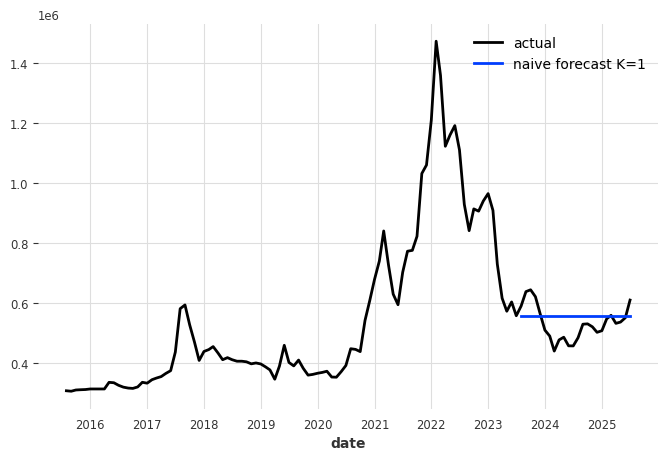

In [4]:
from darts.models import NaiveSeasonal
naive_model = NaiveSeasonal(K=1)  # K는 계절성 주기, 여기서는 1로 바로 직전으로 설정
naive_model.fit(train)
naive_forecast = naive_model.predict(len(val))
plt.figure(figsize=(8, 5))
price.plot(label='actual')
naive_forecast.plot(label='naive forecast K=1')

<Axes: xlabel='date'>

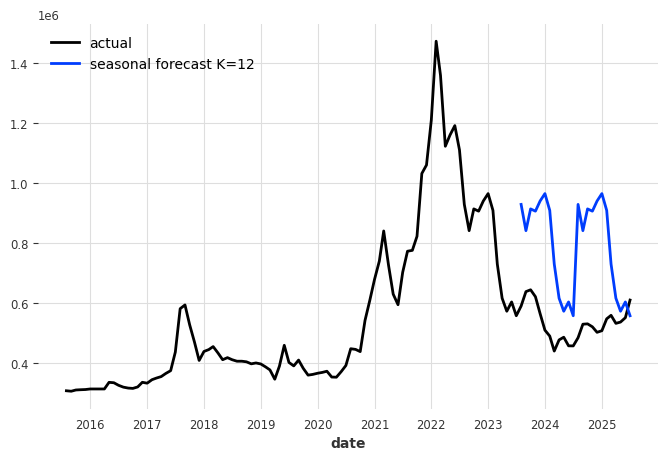

In [5]:
seasonal_model = NaiveSeasonal(K=12)  # K는 계절성 주기, 여기서는 1로 바로 직전으로 설정
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(len(val))
plt.figure(figsize=(8, 5))
price.plot(label='actual')
seasonal_forecast.plot(label='seasonal forecast K=12')

<Axes: xlabel='date'>

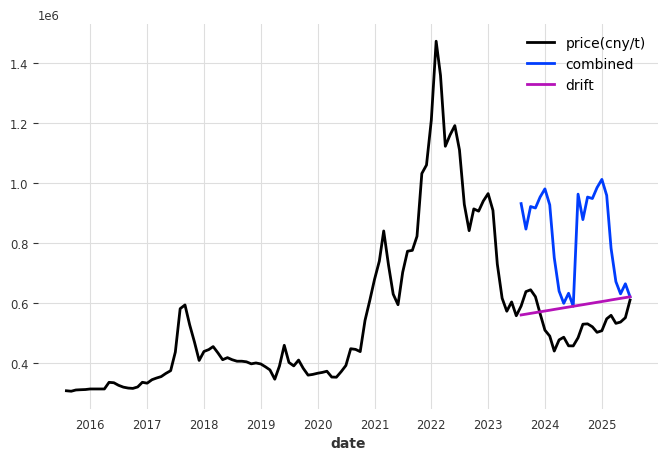

In [6]:
from darts.models import NaiveDrift

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(len(val))

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()
plt.figure(figsize=(8, 5))
price.plot()
combined_forecast.plot(label='combined')
drift_forecast.plot(label='drift')

#### Time-series composition

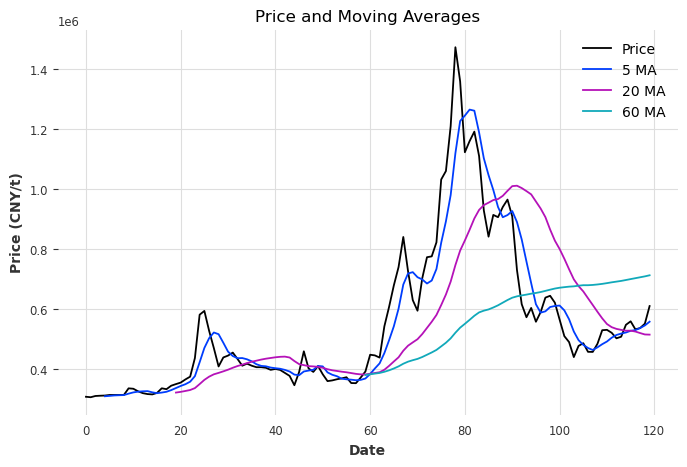

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries

data = pd.read_csv('data.csv', parse_dates=['date'])
price = data['price(cny/t)']

s_date = '2015-08-01'
e_date = '2025-07-01'

ma5 = price.rolling(window=5).mean()
ma20 = price.rolling(window=20).mean()
ma60 = price.rolling(window=60).mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(price, label='Price')
ax.plot(ma5, label='5 MA')
ax.plot(ma20, label='20 MA')
ax.plot(ma60, label='60 MA')
ax.set_title('Price and Moving Averages')
ax.set_xlabel('Date')
ax.set_ylabel('Price (CNY/t)')
ax.legend(loc='best')

<Figure size 900x500 with 0 Axes>

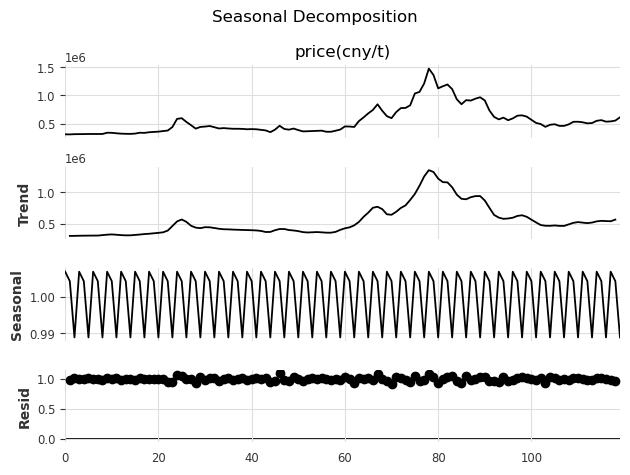

'\nperiod 3 성공적인 분해\nmultiplicative 모델이 데이터에 더 적합하므로 계절 변동이 추세에 비례하여 변하고 있음\n0.99에서 1.01 사이의 변동이므로 약 2%의 계절적 변화\n가격 데이터에서 1-2%의 계절 변동도 실제로는 어느정도 영향\n'

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose

result3 = seasonal_decompose(price, model='multiplicative', period=3)
result6 = seasonal_decompose(price, model='multiplicative', period=6)
result12 = seasonal_decompose(price, model='additive', period=12)

plt.figure(figsize=(9, 5))
result3.plot()
plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

'''
period 3 성공적인 분해
multiplicative 모델이 데이터에 더 적합하므로 계절 변동이 추세에 비례하여 변하고 있음
0.99에서 1.01 사이의 변동이므로 약 2%의 계절적 변화
가격 데이터에서 1-2%의 계절 변동도 실제로는 어느정도 영향
'''

e:\Programs\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: xlabel='date'>

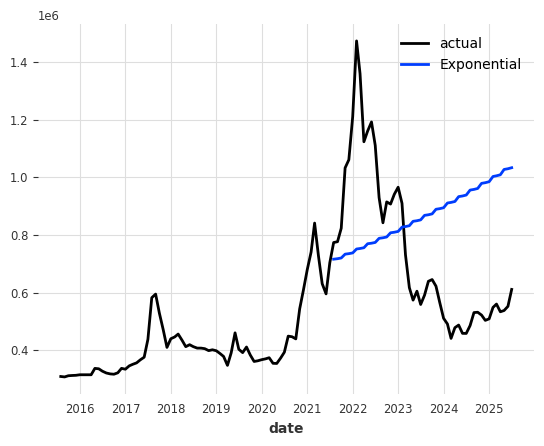

In [27]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

price = TimeSeries.from_dataframe(
    data, 
    time_col='date', 
    value_cols=['price(cny/t)']
)
train, test = price.split_before(pd.Timestamp('2021-08-01'))

# using Holt-Winter's exponential smoothing
model = ExponentialSmoothing(
    trend=ModelMode.MULTIPLICATIVE, 
    seasonal=SeasonalityMode.MULTIPLICATIVE,
    seasonal_periods=3
)
model.fit(train)
pred = model.predict(len(test))
price.plot(label='actual')
pred.plot(label='Exponential')

e:\Programs\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: xlabel='date'>

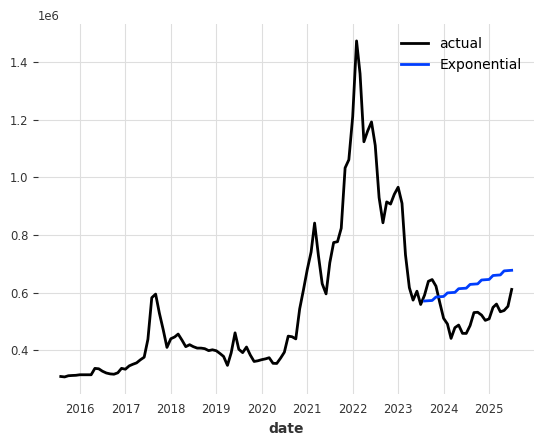

In [26]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

price = TimeSeries.from_dataframe(
    data, 
    time_col='date', 
    value_cols=['price(cny/t)']
)
train, test = price.split_before(pd.Timestamp('2023-08-01'))

# using Holt-Winter's exponential smoothing
model = ExponentialSmoothing(
    trend=ModelMode.MULTIPLICATIVE, 
    seasonal=SeasonalityMode.MULTIPLICATIVE,
    seasonal_periods=3
)
model.fit(train)
pred = model.predict(len(test))
price.plot(label='actual')
pred.plot(label='Exponential')

#### Neural-prophet

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries

df = pd.read_csv('data.csv', parse_dates=['date'])
print(df.info())
print(df.head())
# plt = df.plot(x='date', y='price(cny/t)', figsize=(8, 5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 120 non-null    datetime64[ns]
 1   price(cny/t)         120 non-null    int64         
 2   china-output(kg)     115 non-null    float64       
 3   nonchina-output(kg)  115 non-null    float64       
 4   nev-sales(amount)    119 non-null    float64       
 5   wind-energy-index    120 non-null    float64       
 6   magnet-exports(usd)  119 non-null    float64       
 7   events               0 non-null      float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 7.6 KB
None
        date  price(cny/t)  china-output(kg)  nonchina-output(kg)  \
0 2015-08-01        309000           30076.0               6248.0   
1 2015-09-01        307500           40600.0               8434.0   
2 2015-10-01        311625           70340.0 

In [31]:
from neuralprophet import NeuralProphet

df_simple = df[['date', 'price(cny/t)']].rename(columns={'date': 'ds', 'price(cny/t)': 'y'})
train, test = df_simple[df_simple['ds'] < '2023-08-01'], df_simple[df_simple['ds'] >= '2023-08-01']
m1 = NeuralProphet(
    learning_rate=0.01,
    epochs=207
    )
m1.set_plotting_backend("plotly")
metrics = m1.fit(train)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [98.958]% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_si

Training: 0it [00:00, ?it/s]

In [32]:
df_future = m1.make_future_dataframe(train, n_historic_predictions=True, periods=24)
forecast = m1.predict(df_future)
m1.plot(forecast)

WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [98.958]% of the data.
WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils.return_df_in_original_format) - Returning 

Predicting: 12it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:98: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




In [33]:
m1.plot_parameters(components=['trend', 'seasonality'])

WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:237: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:271: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:475: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Ser

In [ ]:
# import torch
# torch.serialization.add_safe_globals(['neuralprophet.configure.ConfigSeasonality'])

m2 = NeuralProphet(
    weekly_seasonality=False,
    daily_seasonality=False,
    learning_rate=0.05,
    epochs=207
    )
m2.set_plotting_backend("plotly")
metrics = m2.fit(df_simple)
forecast = m2.predict(df_simple)
m2.plot(forecast)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.167]% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 16


Training: 0it [00:00, ?it/s]

WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.167]% of the data.
WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\L

Predicting: 8it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




In [27]:
m2.plot_parameters(components=['trend', 'seasonality'])

WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:237: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:271: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - e:\Programs\anaconda3\Lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:475: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Ser